<a href="https://colab.research.google.com/github/palemsaikumar29-afk/saipalem.github.io/blob/main/MultiAgentOne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

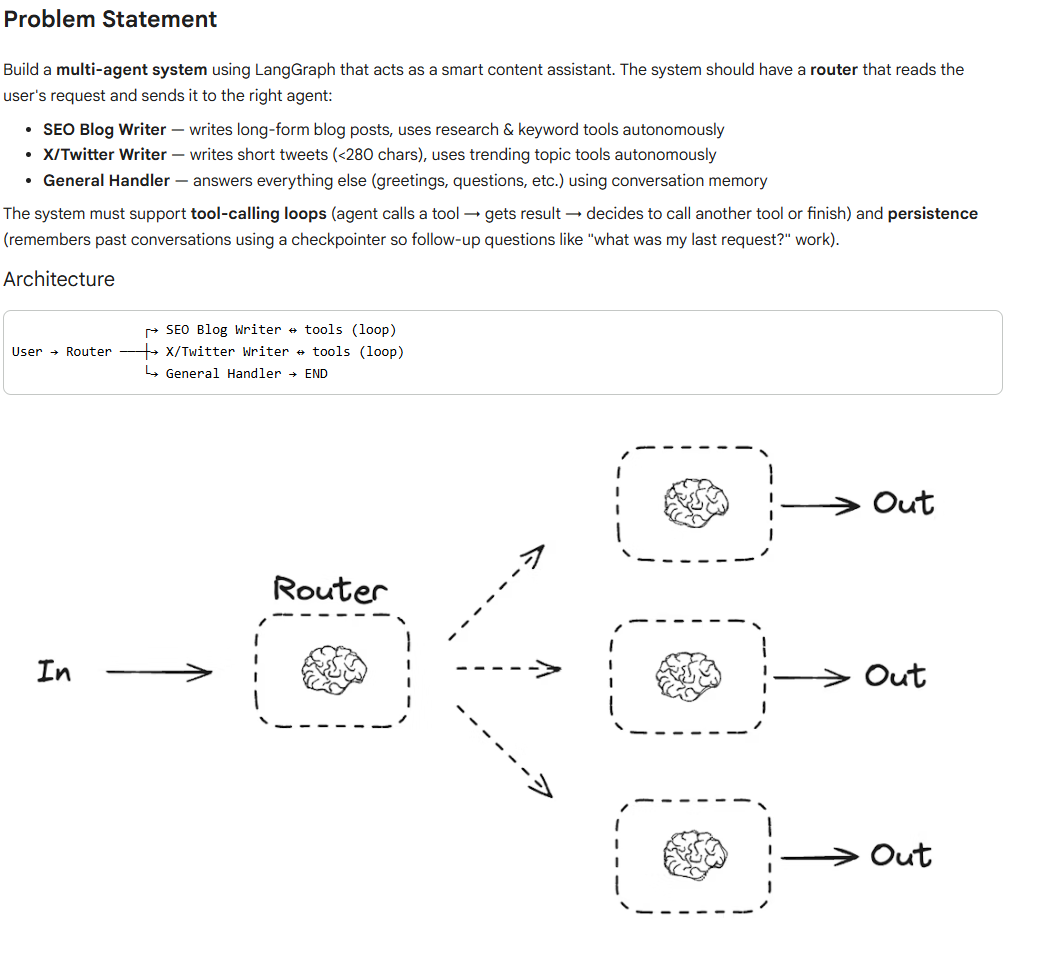

**Install langgraph, langchain, langchain-openai. Configure your LLM.**



```
# MultiAgentSystem
```

# Configure LLM

In [ ]:
! pip install -q -U langgraph langchain langchain-openai deepagents

In [20]:
# Import API Keys

import getpass
import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [21]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    # stream_usage=True,
    temperature=0.2,
    # max_tokens=None,
    # timeout=None,
    # reasoning_effort="low",
    # max_retries=2,
    # api_key="...",  # If you prefer to pass api key in directly
    # base_url="...",
    # organization="...",
    # other params...
)

In [23]:
# Define the state class
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class CopyWriter(TypedDict):
  user_input: str           # The original user request
  route: Literal["seo_blog_writer", "x_blog_writer", "general"]  # Router's decision
  output: str               # Final output from the selected agent
  messages: Annotated[list[BaseMessage], add_messages]